# Exploratory analysis — PTB-XL diagnostic superclasses

Characterisation of the PTB-XL labels and signals used by the supervised
baseline: class prevalence, multi-label co-occurrence, per-lead signal scale and
representative recordings for each of the five diagnostic superclasses.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from deep_ecg.data.labels import SUPERCLASSES, build_label_table, multihot
from deep_ecg.data.sources import build_source
from deep_ecg.data.sources.base import CANONICAL_LEADS
from deep_ecg.evaluation.analysis import label_cooccurrence

ROOT = "../data/raw/ptbxl"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

table = build_label_table(f"{ROOT}/ptbxl_database.csv", f"{ROOT}/scp_statements.csv")
labelled = table[table["superclasses"].apply(len) > 0]
Y = np.stack([multihot(s) for s in labelled["superclasses"]])
len(table), len(labelled)

(21799, 21388)

## Class prevalence

Prevalence of each superclass over the labelled records (multi-label, so the bars do not sum to one).

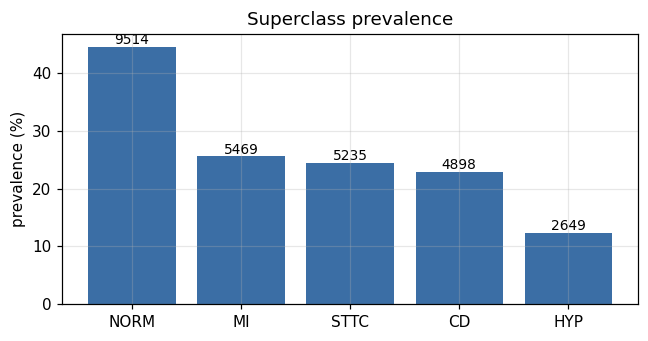

In [2]:
counts = Y.sum(0).astype(int)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(SUPERCLASSES, 100 * counts / len(labelled), color="#3b6ea5")
ax.set_ylabel("prevalence (%)")
for i, c in enumerate(counts):
    ax.text(i, 100 * c / len(labelled) + 0.5, f"{c}", ha="center", fontsize=9)
ax.set_title("Superclass prevalence")
plt.tight_layout(); plt.show()

NORM dominates (~44%) and HYP is the minority (~12%); the imbalance is the main difficulty for HYP in the supervised results.

## Multi-label co-occurrence

Number of records carrying each pair of superclasses (diagonal is the per-class support).

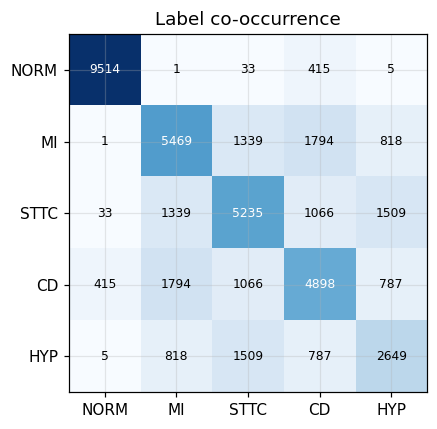

In [3]:
cooc = label_cooccurrence(Y, SUPERCLASSES)
fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(cooc, cmap="Blues")
ax.set_xticks(range(5), SUPERCLASSES); ax.set_yticks(range(5), SUPERCLASSES)
for i in range(5):
    for j in range(5):
        ax.text(j, i, cooc[i, j], ha="center", va="center",
                color="white" if cooc[i, j] > cooc.max()/2 else "black", fontsize=8)
ax.set_title("Label co-occurrence"); plt.tight_layout(); plt.show()

MI co-occurs most with STTC and CD, reflecting genuine multi-morbidity; NORM is by construction almost exclusive.

## Labels per record

Distribution of the number of superclasses assigned to a record.

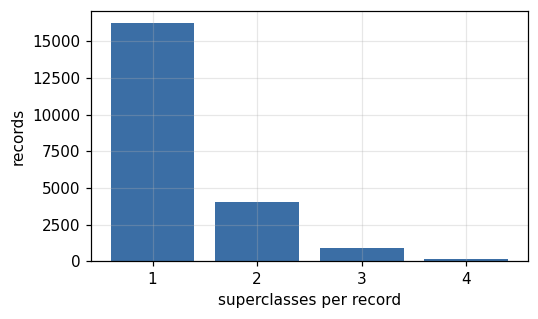

In [4]:
n_labels = Y.sum(1).astype(int)
vals, cnts = np.unique(n_labels, return_counts=True)
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(vals, cnts, color="#3b6ea5")
ax.set_xlabel("superclasses per record"); ax.set_ylabel("records"); ax.set_xticks(vals)
plt.tight_layout(); plt.show()

Most records carry a single superclass, but a substantial tail has two or more — confirming the task is genuinely multi-label.

## Per-lead signal scale

Standard deviation per lead over a sample of recordings (signals are already roughly zero-mean).

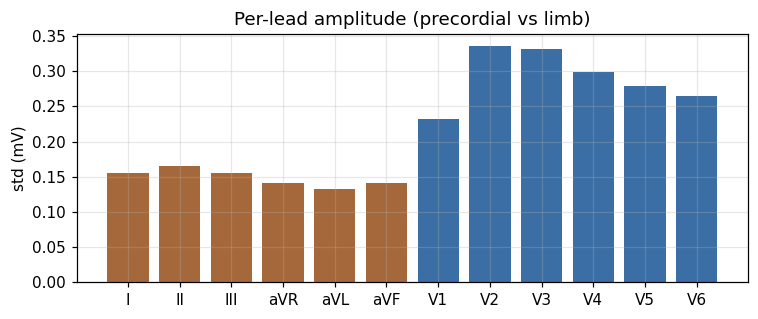

In [5]:
src = build_source("ptbxl", root=ROOT, sampling_rate=100, drop_unlabeled=True)
sample = np.stack([src.get_signal(i) for i in range(4000)])
std = sample.std(axis=(0, 2))
colors = ["#3b6ea5" if l.startswith("V") else "#a5683b" for l in CANONICAL_LEADS]
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(CANONICAL_LEADS, std, color=colors)
ax.set_ylabel("std (mV)"); ax.set_title("Per-lead amplitude (precordial vs limb)")
plt.tight_layout(); plt.show()

Precordial leads (V1–V6) show roughly twice the amplitude of the limb leads, motivating per-lead standardization in the pipeline.

## Representative recordings

A single-label example per superclass, leads II and V4 (100 Hz, 10 s).

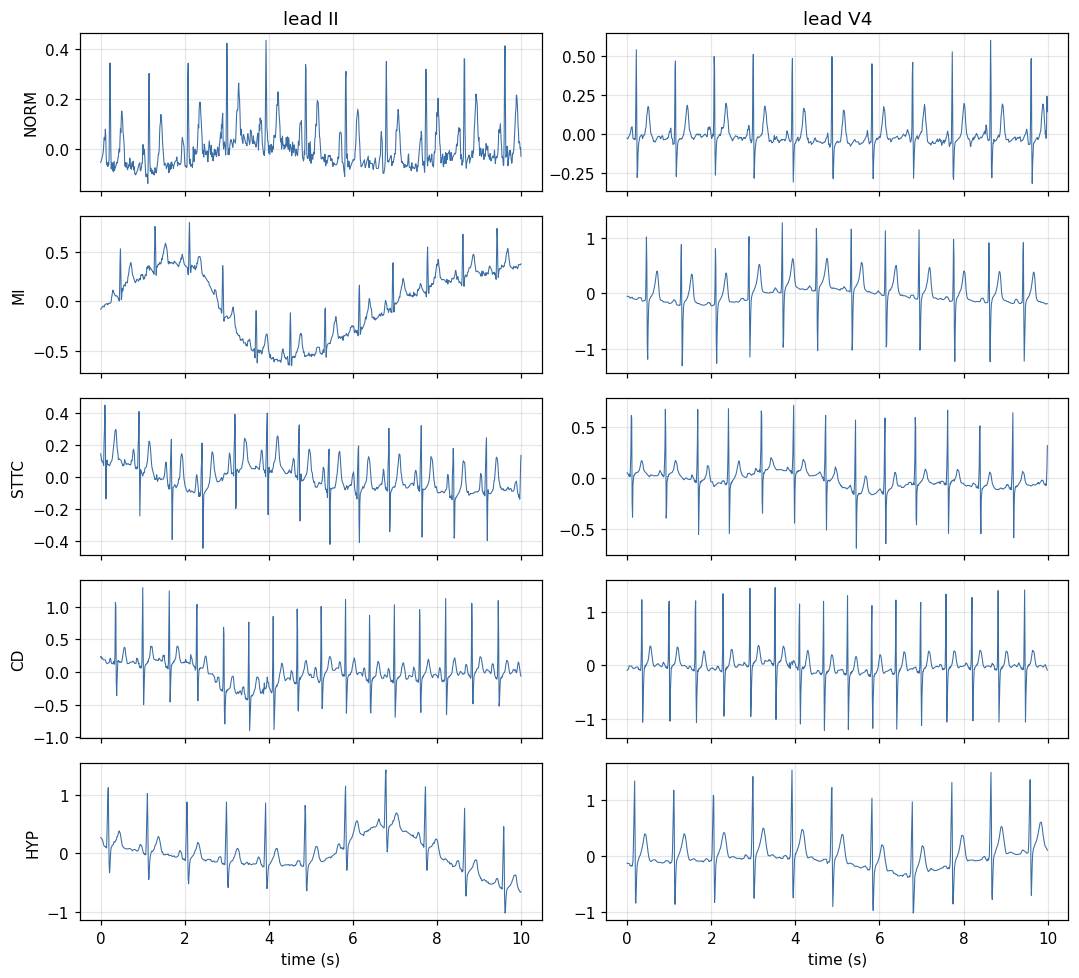

In [6]:
fig, axes = plt.subplots(5, 2, figsize=(10, 9), sharex=True)
t = np.arange(1000) / 100
lead_idx = {l: i for i, l in enumerate(CANONICAL_LEADS)}
for r, cls in enumerate(SUPERCLASSES):
    ecg_id = labelled[labelled["superclasses"].apply(lambda s: s == [cls])].index[0]
    pos = int(np.where(src._ecg_ids == ecg_id)[0][0])
    sig = src._signals[pos]
    for c, lead in enumerate(["II", "V4"]):
        axes[r, c].plot(t, sig[lead_idx[lead]], lw=0.7, color="#3b6ea5")
        axes[r, c].set_ylabel(f"{cls}" if c == 0 else "")
        if r == 0: axes[r, c].set_title(f"lead {lead}")
axes[-1, 0].set_xlabel("time (s)"); axes[-1, 1].set_xlabel("time (s)")
plt.tight_layout(); plt.show()

Morphology differs visibly across superclasses (e.g. ST/T changes in STTC, conduction patterns in CD), which the convolutional encoders learn to discriminate.